In [1]:
import importlib
import MPI_collective
import MPI
import qiskit
import math
from qiskit import QuantumCircuit, transpile, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import *
importlib.reload(MPI_collective)
importlib.reload(MPI)

<module 'MPI' from '/workspaces/qmpi_cpe_kmutt/QMPI_Tinthai_Version/playground/MPI.py'>

In [2]:
# Function พวกนี้ เราเขียนมาเพื่อให้ใช้งานง่ายขึ้นเฉยๆนะ

def qdata_to_circuit(qc, qdata):
    # for inst, qargs, cargs in qdata:
    #     qc.append(inst, qargs, cargs)
    for instr in qdata:
        qc.append(instr.operation, instr.qubits, instr.clbits)

def beautiful_print_result(qc, counts):
    creg_sequence = []
    for creg in qc.cregs:
        creg_sequence.append(f"{creg.name}[{creg.size}]")
    creg_sequence.reverse()
    print("Classical registers (left→right):", " → ".join(creg_sequence))

    print("\nCounts:")
    for bits, count in counts.items():
        print(f"{bits} : {count}")

def prob_single_cbit(counts, target_index):
    # index ของ cbit ตรงกลาง (จากซ้ายไปขวา)
    total = sum(counts.values())

    p0 = sum(v for k, v in counts.items() if k.split()[target_index] == '0') / total
    p1 = sum(v for k, v in counts.items() if k.split()[target_index] == '1') / total

    print(f"P(cbit[{target_index}] = 0) = {p0:.4f}")
    print(f"P(cbit[{target_index}] = 1) = {p1:.4f}")

def mbu(qq, contain_qbit, uncompute_qbit, creg):
    qq.q.h(uncompute_qbit)
    qq.recieveEPR(qq.q, uncompute_qbit, creg)
    qq.q.barrier(contain_qbit, uncompute_qbit) 
    with qq.q.if_test((creg,1)):
        qq.q.z(contain_qbit)
    qq.q.barrier(contain_qbit, uncompute_qbit)
    return qq

def my_qtp2(qq, src, eprsrc, dsc, srccreg):
    qq.cx(src, eprsrc)
    qq.measure(eprsrc, srccreg)
    qq.h(src)
    qq.reset(eprsrc)
    with qq.if_test((srccreg,1)):
        qq.x(dsc)
    qq.measure(src, srccreg)

    # This barrier is very important
    # Because it can help to do phase correction
    qq.barrier(src, eprsrc, dsc) 

    with qq.if_test((srccreg,1)):
        qq.z(dsc)
    qq.barrier(src, eprsrc, dsc)
    return qq

def cat_entangler(qq, eprsrc, dsc, srccreg):
    qq.measure(eprsrc, srccreg)
    qq.reset(eprsrc)
    with qq.if_test((srccreg,1)):
        qq.x(dsc)
    qq.barrier(eprsrc, eprsrc, dsc)
    return qq

def create_epr_and_cat_entangler(qq, src, eprsrc, dsc, srccreg):
    qq.h(eprsrc)
    qq.cx(eprsrc, dsc)
    qq.cx(src, eprsrc)
    qq.measure(eprsrc, srccreg)
    #qq.x(self.EPRdestbit).c_if(self.Csrcbit,1)
    with qq.if_test((srccreg,1)):
        qq.x(dsc)
    qq.barrier()
    return qq

In [3]:
collective_circuit_tinthai = QuantumCircuit()
node0 = QuantumRegister(1, name = "node0")
node1 = QuantumRegister(1, name = "node1")
node2 = QuantumRegister(1, name = "node2")
node3 = QuantumRegister(1, name = "node3")
node0_epr = QuantumRegister(1, name = "node0_epr")
node1_epr = QuantumRegister(1, name = "node1_epr")
node2_epr = QuantumRegister(1, name = "node2_epr")
node3_epr = QuantumRegister(1, name = "node3_epr")
node0_epr_creg = ClassicalRegister(1, name = "node0_epr_creg")
node1_epr_creg = ClassicalRegister(1, name = "node1_epr_creg")
node2_epr_creg = ClassicalRegister(1, name = "node2_epr_creg")
node3_epr_creg = ClassicalRegister(1, name = "node3_epr_creg")

bcast_buffer_epr = QuantumRegister(1, name = "bcast_buffer_epr")
bcast_buffer_epr_creg = ClassicalRegister(1, name = "bcast_buffer_epr_creg")
bcast_device_epr = QuantumRegister(3, name = "bcast_device_epr")
bcast_device_epr_creg = ClassicalRegister(3, name = "bcast_device_epr_creg")
uncompute_creg = ClassicalRegister(1, name = "uncompute_creg")

collective_circuit_tinthai.add_register(node0, node1, node2, node3, node0_epr, node1_epr, node2_epr, node3_epr, bcast_buffer_epr, bcast_device_epr)
collective_circuit_tinthai.add_register(node0_epr_creg, node1_epr_creg, node2_epr_creg, node3_epr_creg, bcast_buffer_epr_creg, bcast_device_epr_creg, uncompute_creg)

# Initiate ให้ node1[0] มีโอกาส ket(0) ~75%
collective_circuit_tinthai.rx(math.pi/4, node0[0])   # หมุนแกน X มุม π/4 บน qubit 0
collective_circuit_tinthai.ry(math.pi/4, node0[0])   # หมุนแกน Y มุม π/4 บน qubit 0

# EPR Pair Preparation
collective_circuit_tinthai.h(bcast_device_epr[0])
collective_circuit_tinthai.h(bcast_device_epr[1])
collective_circuit_tinthai.h(bcast_device_epr[2])
collective_circuit_tinthai.cx(bcast_device_epr[0], node1[0])
collective_circuit_tinthai.cx(bcast_device_epr[1], node2[0])
collective_circuit_tinthai.cx(bcast_device_epr[2], node3[0])
collective_circuit_tinthai.barrier()

# Copy to buffer_epr
collective_circuit_tinthai = create_epr_and_cat_entangler(collective_circuit_tinthai, node0[0], node0_epr[0], bcast_buffer_epr[0], node0_epr_creg[0])

# Device setup
collective_circuit_tinthai.barrier()
collective_circuit_tinthai.cx(bcast_buffer_epr[0], bcast_device_epr[0])
collective_circuit_tinthai.cx(bcast_buffer_epr[0], bcast_device_epr[1])
collective_circuit_tinthai.cx(bcast_buffer_epr[0], bcast_device_epr[2])
# collective_circuit_tinthai.h(bcast_buffer_epr[0])
# collective_circuit_tinthai.reset(bcast_buffer_epr[0])

# Bcast
collective_circuit_tinthai.barrier()
collective_circuit_tinthai = cat_entangler(collective_circuit_tinthai, bcast_device_epr[0], node1_epr[0], bcast_device_epr_creg[0])
collective_circuit_tinthai = cat_entangler(collective_circuit_tinthai, bcast_device_epr[1], node2_epr[0], bcast_device_epr_creg[1])
collective_circuit_tinthai = cat_entangler(collective_circuit_tinthai, bcast_device_epr[2], node3_epr[0], bcast_device_epr_creg[2])

collective_circuit_tinthai.cx(node1_epr[0], node1[0])
collective_circuit_tinthai.cx(node2_epr[0], node2[0])
collective_circuit_tinthai.cx(node3_epr[0], node3[0])

# Uncompute
collective_circuit_tinthai.barrier()
collective_circuit_tinthai.h(bcast_buffer_epr[0])
collective_circuit_tinthai.measure(bcast_buffer_epr[0], uncompute_creg[0])
collective_circuit_tinthai.reset(bcast_buffer_epr[0])
collective_circuit_tinthai.reset(node0_epr[0])
collective_circuit_tinthai.reset(node1_epr[0])
collective_circuit_tinthai.reset(node2_epr[0])
collective_circuit_tinthai.reset(node3_epr[0])
with collective_circuit_tinthai.if_test((uncompute_creg,1)):
    collective_circuit_tinthai.z(node0[0])

# การวัดด้วยตัวเอง
collective_circuit_tinthai.barrier()
collective_circuit_tinthai.measure(node0[0], node0_epr_creg[0])
collective_circuit_tinthai.measure(node1[0], node1_epr_creg[0])
collective_circuit_tinthai.measure(node2[0], node2_epr_creg[0])
collective_circuit_tinthai.measure(node3[0], node3_epr_creg[0])

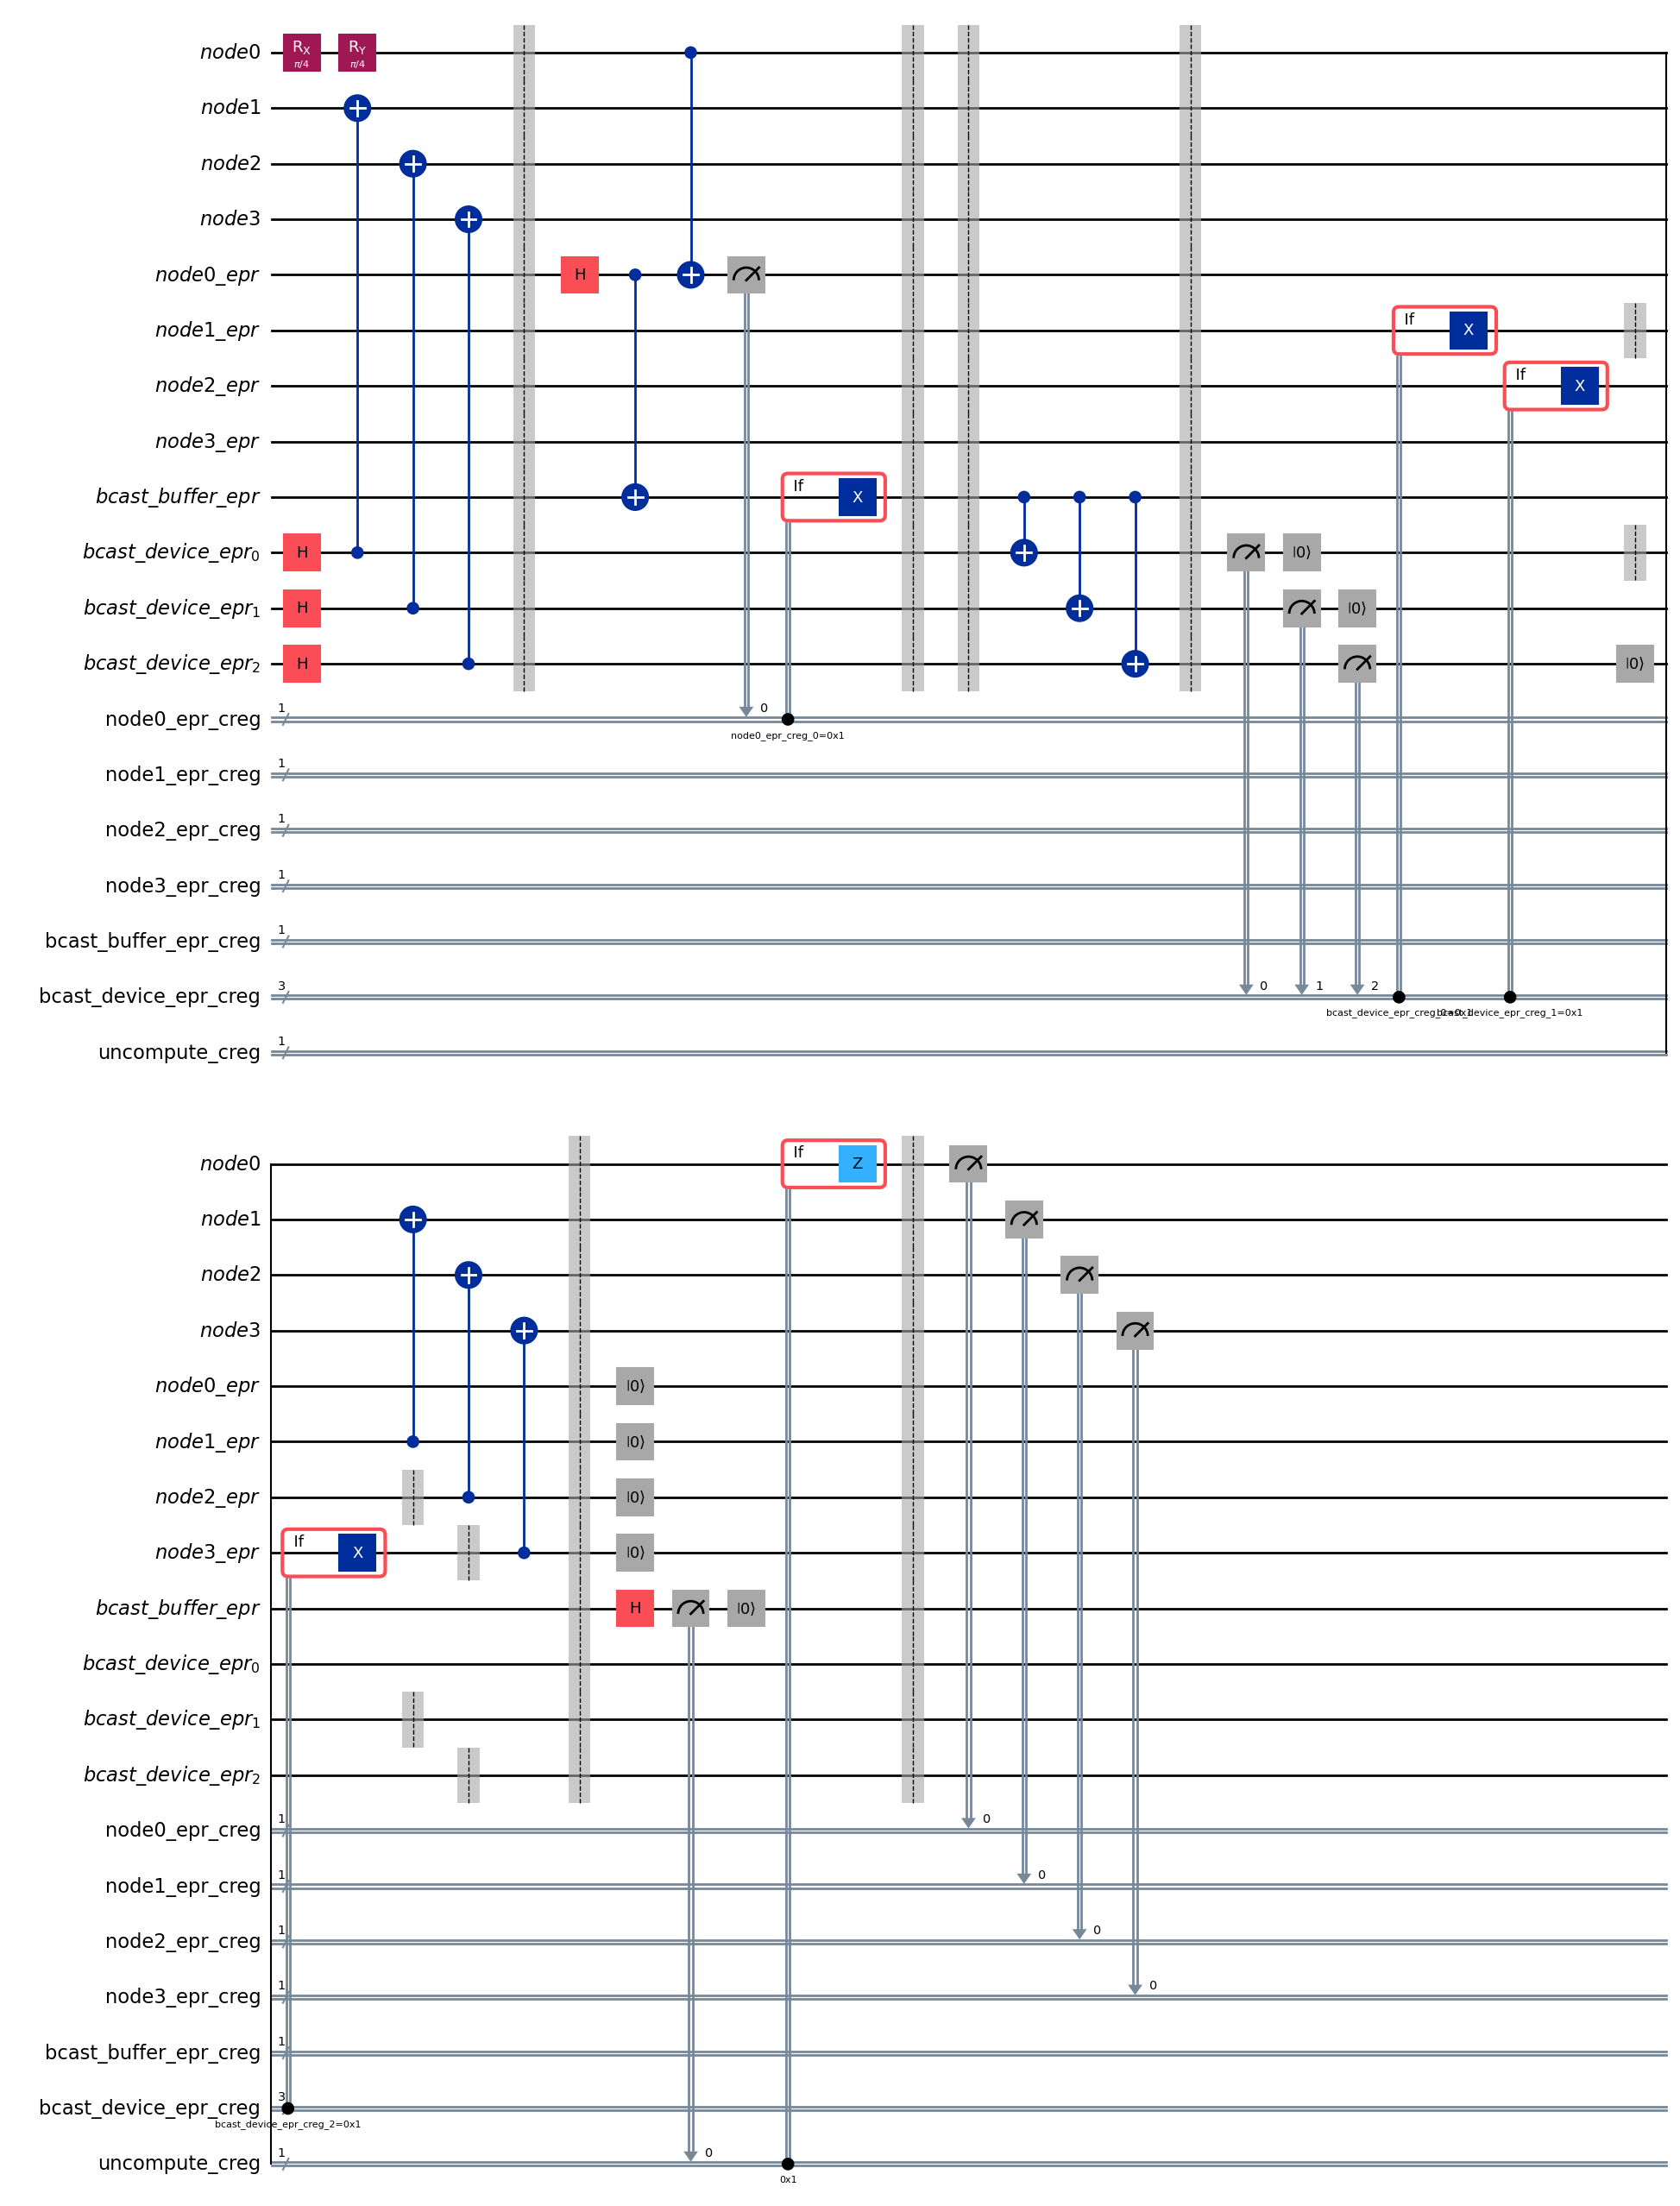

In [4]:
collective_circuit_tinthai.draw("mpl")

In [21]:
sim = FakeKyiv()
collective_circuit_tinthai_ready2rn = transpile(collective_circuit_tinthai, backend=sim, optimization_level=3)
result = sim.run(collective_circuit_tinthai_ready2rn).result()
counts = result.get_counts()
# beautiful_print_result(collective_circuit_tinthai, counts)
# print(counts)
## ถ้าใส่ add_register(c0,c1,c2) ผลลัพธ์จะเป็น 'c2, c1, c0'

print("Node 0 Prob:")
prob_single_cbit(counts, target_index=6)
print("")

print("Node 1 Prob:")
prob_single_cbit(counts, target_index=5)
print("")

print("Node 2 Prob:")
prob_single_cbit(counts, target_index=4)
print("")

print("Node 3 Prob:")
prob_single_cbit(counts, target_index=3)
print("")

Node 0 Prob:
P(cbit[6] = 0) = 0.7334
P(cbit[6] = 1) = 0.2666

Node 1 Prob:
P(cbit[5] = 0) = 0.7021
P(cbit[5] = 1) = 0.2979

Node 2 Prob:
P(cbit[4] = 0) = 0.6992
P(cbit[4] = 1) = 0.3008

Node 3 Prob:
P(cbit[3] = 0) = 0.6855
P(cbit[3] = 1) = 0.3145



In [741]:
from qiskit_aer import AerSimulator
from qiskit import transpile

# 1️⃣ ลบการวัดออก (เพื่อดูสถานะก่อน collapse)
circ_no_measure = collective_circuit_tinthai.remove_final_measurements(inplace=False)

# 2️⃣ บอกให้ simulator เก็บ statevector
circ_no_measure.save_statevector() 

# 3️⃣ ใช้ simulator แบบ statevector
sim_sv = AerSimulator(method='statevector')

# 4️⃣ transpile และรัน
ready_sv = transpile(circ_no_measure, sim_sv)
result_sv = sim_sv.run(ready_sv).result()

# 5️⃣ ดึงข้อมูล statevector ออกมา
statevector = result_sv.data(0)['statevector']
# print(statevector)

from qiskit.quantum_info import Statevector
import numpy as np

# statevector จากผล simulation
vec = Statevector(statevector)

# แสดงเฉพาะค่าสำคัญ
for i, amp in enumerate(vec.data):
    if not np.isclose(abs(amp), 0):  # ข้ามค่าที่แทบเป็นศูนย์
        print(f"|{i:0{vec.num_qubits}b}> : {amp}")

|000000000000> : (0.8535533905932738+0.14644660940672627j)
|000000001111> : (0.3535533905932736-0.3535533905932737j)


In [5]:
collective_circuit = QuantumCircuit()
nodes_count = 4
qnode = {}
qnode_probe = {}
for i in range(nodes_count):
    qnode[i] = QuantumRegister(1, name = f"node{i}")
    collective_circuit.add_register(qnode[i])
for i in range(nodes_count):
    qnode_probe[i] = ClassicalRegister(1, name = f"node{i}_probe")
    collective_circuit.add_register(qnode_probe[i])

# Initiate ให้ node1[0] มีโอกาส ket(0) ~75%
collective_circuit.rx(math.pi/4, qnode[0][0])   # หมุนแกน X มุม π/4 บน qubit 0
collective_circuit.ry(math.pi/4, qnode[0][0])   # หมุนแกน X มุม π/4 บน qubit 0

collective_class_yushi = MPI_collective.CollectiveMPI(collective_circuit)
# collective_class.q.draw('mpl')
# print(collective_class.length)

# Broadcast 
operation = collective_class_yushi.brodcast([qnode[0][0], qnode[1][0], qnode[2][0], qnode[3][0]])

collective_class_yushi.q.barrier()
collective_class_yushi.q.measure(qnode[0][0], qnode_probe[0])
collective_class_yushi.q.measure(qnode[1][0], qnode_probe[1])
collective_class_yushi.q.measure(qnode[2][0], qnode_probe[2])
collective_class_yushi.q.measure(qnode[3][0], qnode_probe[3])
# qdata_to_circuit(collective_class.q, operation)

In [6]:
sim = FakeKyiv()
collective_circuit_tinthai_ready2rn = transpile(collective_circuit_tinthai, backend=sim, optimization_level=3)
collective_circuit_yushi_ready2run = transpile(collective_class_yushi.q, backend=sim, optimization_level=3)

from supermarq import *

bcast_tinthai = [
  converters.compute_communication_with_qiskit(collective_circuit_tinthai_ready2rn),
  converters.compute_depth_with_qiskit(collective_circuit_tinthai_ready2rn),
  converters.compute_entanglement_with_qiskit(collective_circuit_tinthai_ready2rn),
]

bcast_yushi = [
  converters.compute_communication_with_qiskit(collective_circuit_yushi_ready2run),
  converters.compute_depth_with_qiskit(collective_circuit_yushi_ready2run),
  converters.compute_entanglement_with_qiskit(collective_circuit_yushi_ready2run),
]

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [828]:
print(bcast_tinthai)
print(bcast_yushi)

[0.0014998125234345708, 0.55, 0.11904761904761904]
[0.000999875015623047, 0.7333333333333333, 0.11029411764705882]


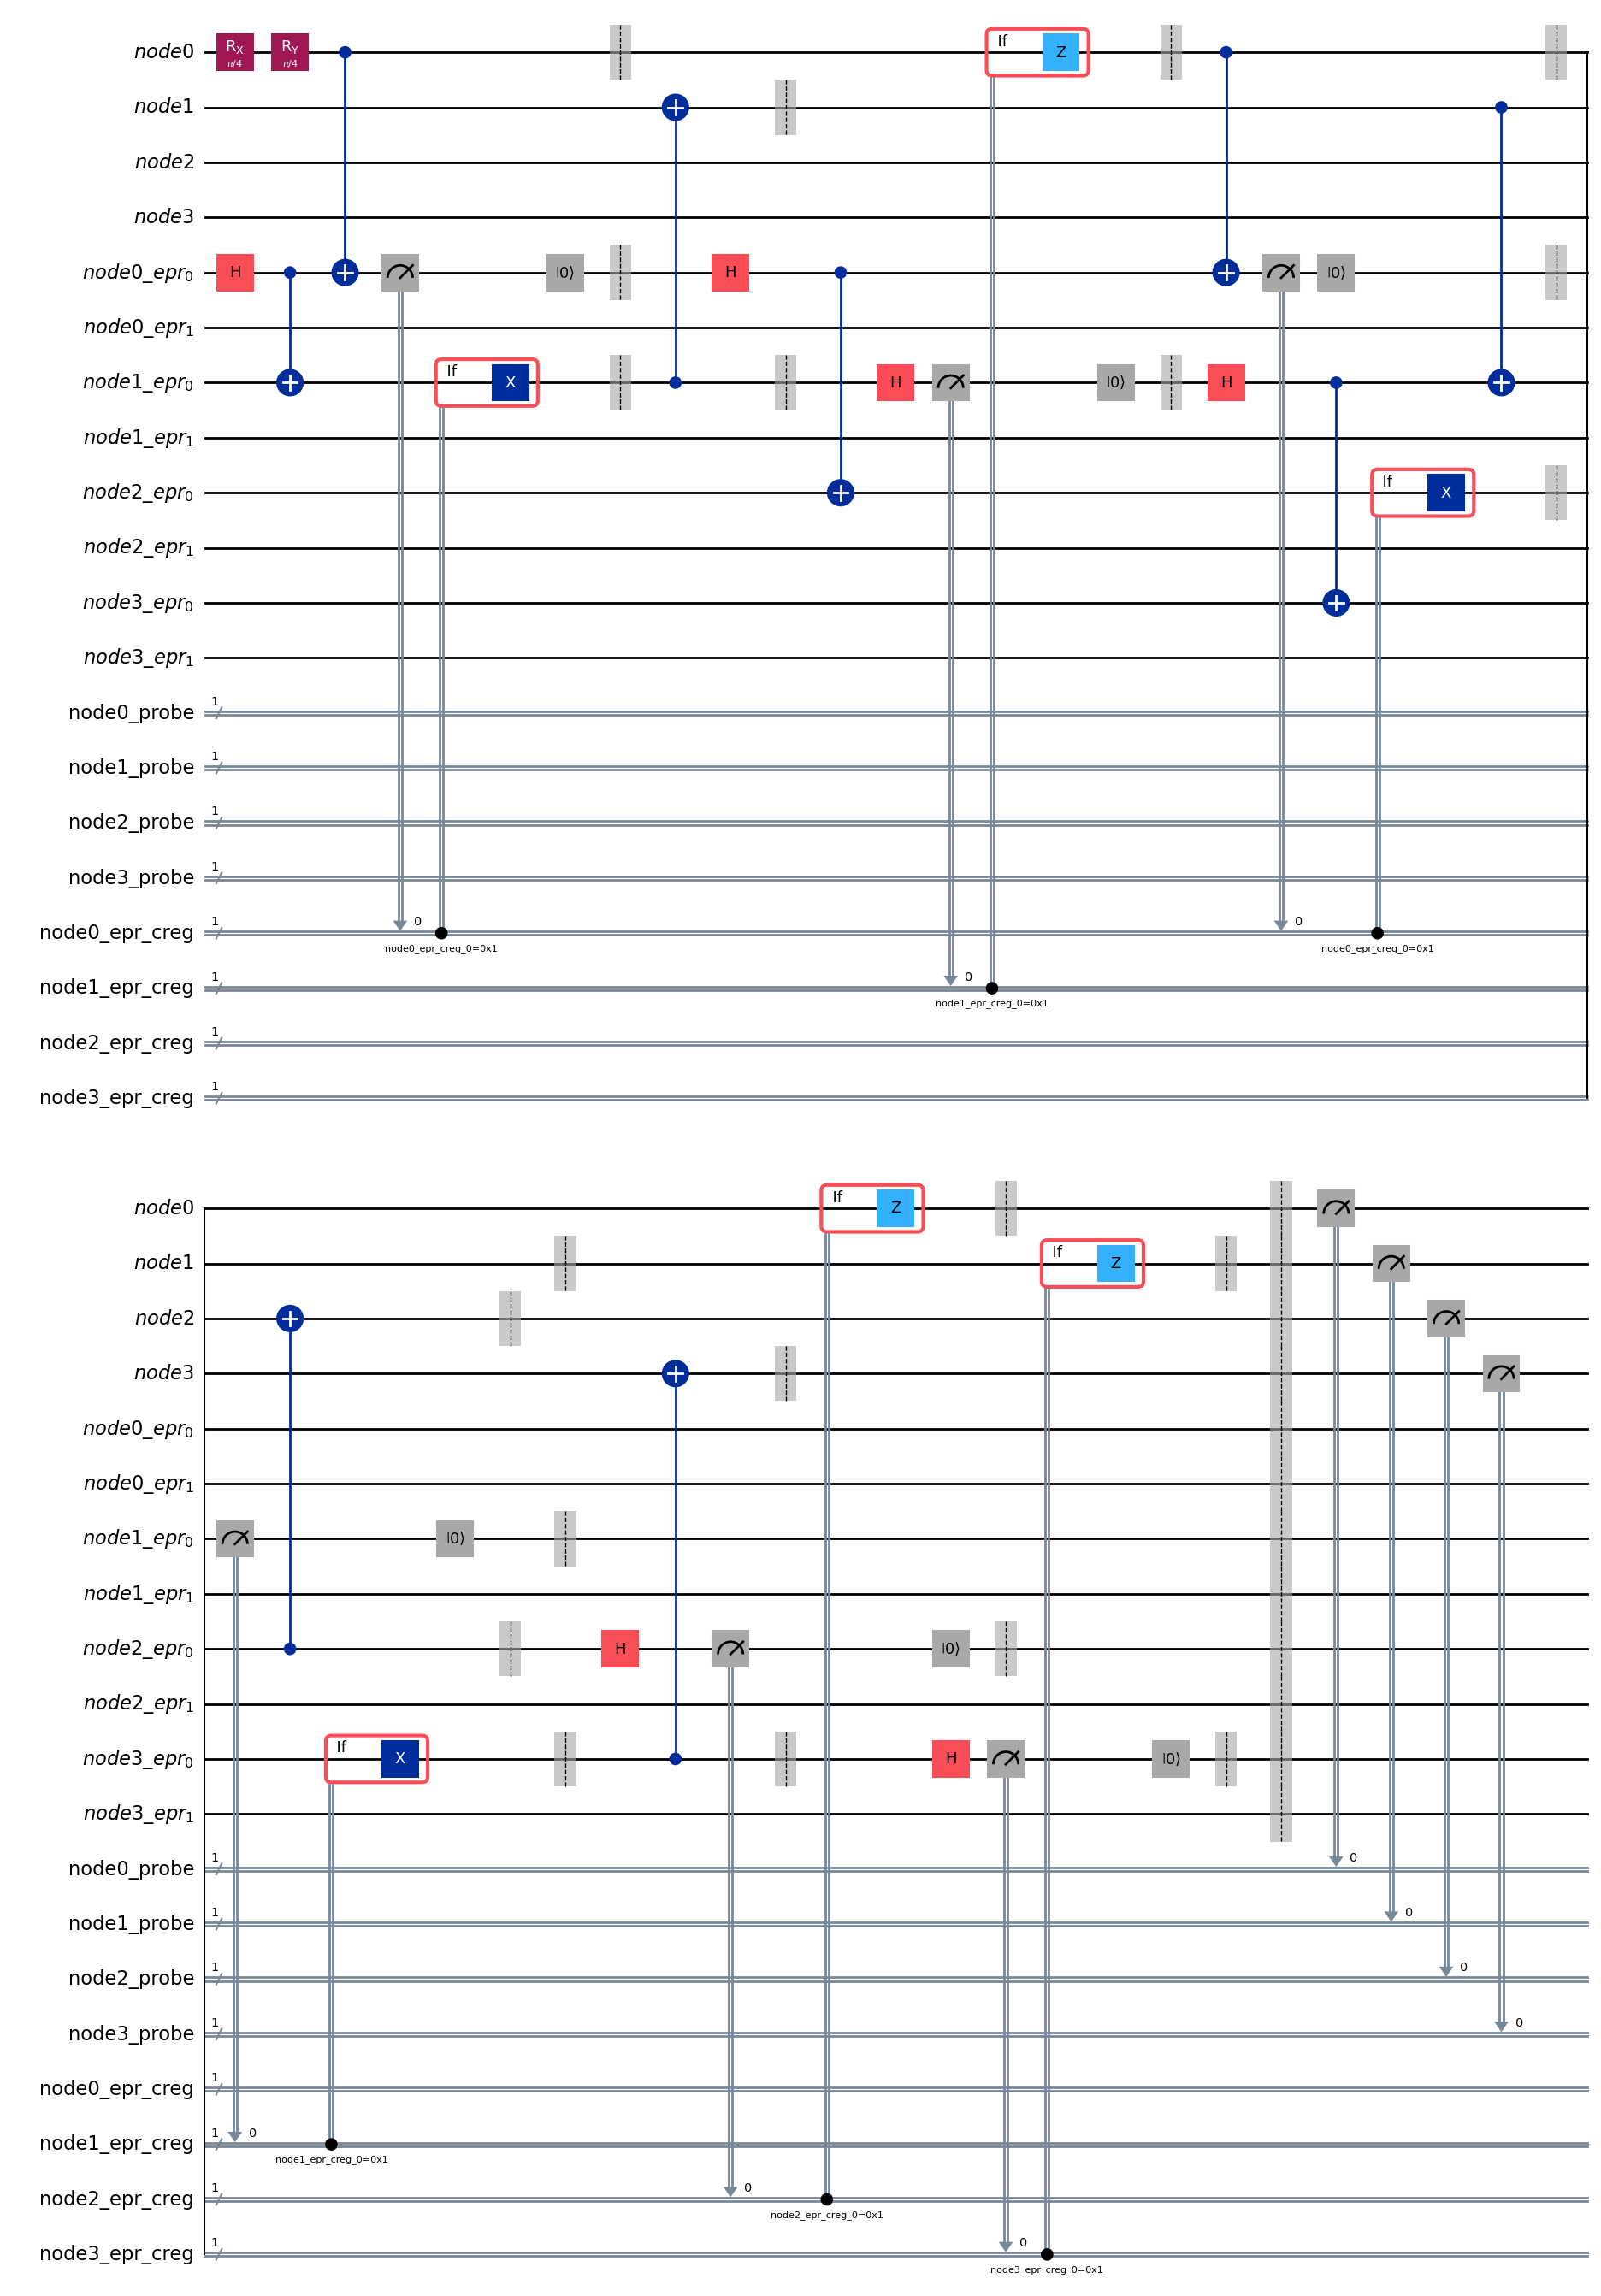

In [ ]:
collective_class_yushi.q.draw("mpl")

In [12]:
sim = FakeKyiv()
collective_circuit_yushi_ready2run = transpile(collective_class_yushi.q, backend=sim, optimization_level=3)
result = sim.run(collective_circuit_yushi_ready2run).result()
counts = result.get_counts()
# beautiful_print_result(collective_circuit_yushi_ready2run, counts)

print("Node 0 Prob:")
prob_single_cbit(counts, target_index=7)
print("")

print("Node 1 Prob:")
prob_single_cbit(counts, target_index=6)
print("")

print("Node 2 Prob:")
prob_single_cbit(counts, target_index=5)
print("")

print("Node 3 Prob:")
prob_single_cbit(counts, target_index=4)
print("")

Node 0 Prob:
P(cbit[7] = 0) = 0.7393
P(cbit[7] = 1) = 0.2607

Node 1 Prob:
P(cbit[6] = 0) = 0.7314
P(cbit[6] = 1) = 0.2686

Node 2 Prob:
P(cbit[5] = 0) = 0.7324
P(cbit[5] = 1) = 0.2676

Node 3 Prob:
P(cbit[4] = 0) = 0.7197
P(cbit[4] = 1) = 0.2803



In [ ]:
from qiskit_aer import AerSimulator
from qiskit import transpile

# 1️⃣ ลบการวัดออก (เพื่อดูสถานะก่อน collapse)
circ_no_measure = collective_class_yushi.q.remove_final_measurements(inplace=False)

# 2️⃣ บอกให้ simulator เก็บ statevector
circ_no_measure.save_statevector() 

# 3️⃣ ใช้ simulator แบบ statevector
sim_sv = AerSimulator(method='statevector')

# 4️⃣ transpile และรัน
ready_sv = transpile(circ_no_measure, sim_sv)
result_sv = sim_sv.run(ready_sv).result()

# 5️⃣ ดึงข้อมูล statevector ออกมา
statevector = result_sv.data(0)['statevector']
# print(statevector)

from qiskit.quantum_info import Statevector
import numpy as np

# statevector จากผล simulation
vec = Statevector(statevector)

# แสดงเฉพาะค่าสำคัญ
for i, amp in enumerate(vec.data):
    if not np.isclose(abs(amp), 0):  # ข้ามค่าที่แทบเป็นศูนย์
        print(f"|{i:0{vec.num_qubits}b}> : {amp}")

|000000000000> : (0.8535533905932738+0.14644660940672632j)
|000000001111> : (0.35355339059327356-0.3535533905932739j)


#Fidelity benchmark

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import hellinger_fidelity

# 1. SETUP
backend = FakeKyiv()
noisy_sim = AerSimulator.from_backend(backend)
ideal_sim = AerSimulator()

def get_marginal_counts(counts, relevant_indices):
    new_counts = {}
    for bitstring, count in counts.items():
        # Clean string & reverse (เพื่อให้ Index 0 คือบิตขวาสุด)
        # ตัวอย่าง: Qiskit '110' (c2,c1,c0) -> clean '011' (c0,c1,c2)
        clean_bits = bitstring.replace(" ", "")[::-1]
        
        key_list = []
        for i in relevant_indices:
            # CHECK BOUNDS: ห้ามใส่ index เกินจริงเด็ดขาด
            if i >= len(clean_bits):
                raise ValueError(f"❌ Error: คุณขอ Index {i} แต่วงจรมีแค่ {len(clean_bits)} bits (0-{len(clean_bits)-1})")
            
            key_list.append(clean_bits[i])
        
        # ประกอบร่างกลับ (MSB ซ้าย, LSB ขวา ตาม Qiskit Convention)
        final_key = "".join(key_list[::-1])
        new_counts[final_key] = new_counts.get(final_key, 0) + count
        
    return new_counts

def calculate_metrics(counts_ideal, counts_noisy):
    fid = hellinger_fidelity(counts_ideal, counts_noisy)
    
    # PST Calculation
    total_shots = sum(counts_noisy.values())
    valid_shots = 0
    # นับเฉพาะ state ที่ปรากฏใน ideal (Ground Truth)
    for state in counts_ideal.keys():
        valid_shots += counts_noisy.get(state, 0)
    
    pst = valid_shots / total_shots if total_shots > 0 else 0
    return fid, pst

def analyze_circuit(qc, relevant_indices, name="Circuit"):
    print(f"\nAnalyzing: {name}...")
    
    # Transpile
    t_qc = transpile(qc, backend, optimization_level=1)
    
    # 1. Run Ideal
    t_ideal = transpile(qc, ideal_sim)
    res_ideal = ideal_sim.run(t_ideal, shots=4096).result().get_counts()
    try:
        marg_ideal = get_marginal_counts(res_ideal, relevant_indices)
    except ValueError as e:
        print(e)
        return None

    # 2. Run Noisy
    res_noisy = noisy_sim.run(t_qc, shots=4096).result().get_counts()
    marg_noisy = get_marginal_counts(res_noisy, relevant_indices) # ไม่ต้อง try เพราะ ideal ผ่านแล้ว

    # 3. Stats
    fid, pst = calculate_metrics(marg_ideal, marg_noisy)
    
    print(f"  > Hellinger Fidelity: {fid:.4f}")
    print(f"  > PST: {pst:.4f} ({pst*100:.2f}%)")
    
    return {
        "name": name,
        "fidelity": fid,
        "pst": pst,
        "counts_ideal": marg_ideal,
        "counts_noisy": marg_noisy
    }

data_tree = analyze_circuit(collective_class_yushi.q, [6,5,4,3], "Yu Shi (Tree)")
data_switch = analyze_circuit(collective_circuit_tinthai, [7,6,5,4], "Your Work (Switch)")

if data_tree and data_switch:
    print("\n--- Result ---")
    print(f"Yu Shi Fidelity: {data_tree['fidelity']:.4f}")
    print(f"Switch Fidelity: {data_switch['fidelity']:.4f}")


Analyzing: Yu Shi (Tree)...
  > Hellinger Fidelity: 0.9953
  > PST: 1.0000 (100.00%)

Analyzing: Your Work (Switch)...
  > Hellinger Fidelity: 0.9991
  > PST: 1.0000 (100.00%)

--- Result ---
Yu Shi Fidelity: 0.9953
Switch Fidelity: 0.9991


In [60]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import (NoiseModel, QuantumError, ReadoutError,
    pauli_error, depolarizing_error, thermal_relaxation_error)
from qiskit.quantum_info import hellinger_fidelity

# ==========================================
# 1. สร้าง "Fake Trapped Ion" Backend
# ==========================================
def create_trapped_ion_backend(n_qubits, error_rate=0.01):
    # 1. สร้าง Coupling Map แบบ All-to-All (เชื่อมทุกตัวหาทุกตัว)
    # นี่คือหัวใจของ Trapped Ion ครับ
    coupling_map = []
    for i in range(n_qubits):
        for j in range(n_qubits):
            if i != j:
                coupling_map.append([i, j])
    
    # 2. สร้าง Noise Model จำลอง (เพื่อให้ผลลัพธ์ไม่เป็น 100% ตลอด)
    noise_model = NoiseModel()
    
    # Error สำหรับ 1-qubit gate (น้อยๆ หน่อย)
    error_1q = depolarizing_error(error_rate/10, 1)
    noise_model.add_all_qubit_quantum_error(error_1q, ['u1', 'u2', 'u3', 'h', 'x', 'z'])
    
    # Error สำหรับ 2-qubit gate (CNOT) - นี่คือตัวแปรสำคัญ
    error_2q = depolarizing_error(error_rate, 2)
    noise_model.add_all_qubit_quantum_error(error_2q, ['cx'])
    
    # 3. สร้าง Simulator จาก Spec ที่เรากำหนด
    sim = AerSimulator(noise_model=noise_model, coupling_map=coupling_map)
    return sim

# สร้าง Backend จำลองที่มี 7 Qubits (เชื่อมกันหมด!)
# error_rate 0.02 = 2% error ต่อ CNOT
trapped_ion_sim = create_trapped_ion_backend(14, error_rate=0.04)
ideal_sim = AerSimulator() # สำหรับเทียบ Ground Truth

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import hellinger_fidelity

# 1. SETUP
# backend = FakeTorino()
# noisy_sim = AerSimulator.from_backend(backend)
noisy_sim = trapped_ion_sim
ideal_sim = AerSimulator()

def get_marginal_counts(counts, relevant_indices):
    new_counts = {}
    for bitstring, count in counts.items():
        clean_bits = bitstring.replace(" ", "")[::-1]
        key_list = []
        for i in relevant_indices:
            if i >= len(clean_bits):
                raise ValueError(f"❌ Index {i} out of bounds.")
            key_list.append(clean_bits[i])
        final_key = "".join(key_list[::-1])
        new_counts[final_key] = new_counts.get(final_key, 0) + count
    return new_counts

def calculate_metrics(counts_ideal, counts_noisy):
    fid = hellinger_fidelity(counts_ideal, counts_noisy)
    total_shots = sum(counts_noisy.values())
    valid_shots = sum(counts_noisy.get(state, 0) for state in counts_ideal.keys())
    pst = valid_shots / total_shots if total_shots > 0 else 0
    return fid, pst

def run_experiment(qc, relevant_indices, iterations=5):
    fidelities = []
    psts = []
    
    # ดูจำนวน Gate หลัง Transpile (ใช้รอบแรกเป็นตัวแทน)
    t_qc_example = transpile(qc, backend, optimization_level=1, seed_transpiler=42)
    gate_counts = t_qc_example.count_ops()
    cnot_count = gate_counts.get('cx', 0)
    
    for i in range(iterations):
        # 1. Ideal Run (ทำครั้งเดียวหรือทำทุกครั้งก็ได้เพื่อความชัวร์)
        t_ideal = transpile(qc, ideal_sim)
        res_ideal = ideal_sim.run(t_ideal, shots=4096).result().get_counts()
        marg_ideal = get_marginal_counts(res_ideal, relevant_indices)

        # 2. Noisy Run (สุ่ม Seed ของ Transpiler เพื่อดูความเสถียร)
        t_noisy = transpile(qc, backend, optimization_level=1, seed_transpiler=i+100)
        res_noisy = noisy_sim.run(t_noisy, shots=4096).result().get_counts()
        marg_noisy = get_marginal_counts(res_noisy, relevant_indices)

        fid, pst = calculate_metrics(marg_ideal, marg_noisy)
        fidelities.append(fid)
        psts.append(pst)

    return {
        "fid_mean": np.mean(fidelities),
        "fid_std": np.std(fidelities),
        "pst_mean": np.mean(psts),
        "cnot": cnot_count
    }

# --- การรันเปรียบเทียบ ---

# สมมติว่า collective_class_yushi.q และ collective_circuit_tinthai คือวงจรของคุณ
results = {}

# วิเคราะห์วงจร A
res_tree = run_experiment(collective_class_yushi.q, [6,5,4,3,2,1,0])
results["Yu Shi (Tree)"] = res_tree

# วิเคราะห์วงจร B
res_switch = run_experiment(collective_circuit_tinthai, [7,6,5,4,3,2,1,0])
results["Your Work (Switch)"] = res_switch

# --- PRINT SUMMARY ---
print(f"{'Circuit Name':<20} | {'Fidelity (Avg)':<15} | {'PST (Avg)':<10} | {'CNOT Count'}")
print("-" * 65)
for name, data in results.items():
    print(f"{name:<20} | {data['fid_mean']:.4f} ± {data['fid_std']:.4f} | {data['pst_mean']*100:>6.2f}% | {data['cnot']}")

Circuit Name         | Fidelity (Avg)  | PST (Avg)  | CNOT Count
-----------------------------------------------------------------
Yu Shi (Tree)        | 0.9947 ± 0.0014 |  99.68% | 0
Your Work (Switch)   | 0.9947 ± 0.0009 |  99.61% | 0


In [53]:
# 1. SETUP
# backend = FakeTorino()
# noisy_sim = AerSimulator.from_backend(backend)
# ideal_sim = AerSimulator()

# Transpile 
qc_yushi_transpiled = transpile(collective_class_yushi.q, backend=noisy_sim, optimization_level=3)
qc_tinthai_transpiled = transpile(collective_circuit_tinthai, backend=noisy_sim, optimization_level=3)

print("--- YU SHI ---")
print("Depth:", qc_yushi_transpiled.depth())
print("Total Gates:", qc_yushi_transpiled.count_ops())

print("\n--- TINTHAI (SWITCH) ---")
print("Depth:", qc_tinthai_transpiled.depth())
print("Total Gates:", qc_tinthai_transpiled.count_ops())

--- YU SHI ---
Depth: 46
Total Gates: OrderedDict({'rz': 40, 'sx': 32, 'cz': 12, 'measure': 10, 'barrier': 10, 'if_else': 6, 'reset': 6})

--- TINTHAI (SWITCH) ---
Depth: 64
Total Gates: OrderedDict({'sx': 59, 'rz': 51, 'cz': 26, 'barrier': 9, 'measure': 9, 'reset': 8, 'if_else': 5})
